# Investment Universe Construction
Build the Europe investment universe using firms that are present in returns, emissions, revenues, and market value datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize

BASE_DIR = Path.cwd().parent
CLEAN_DIR = BASE_DIR / "data_clean"
RAW_DIR = BASE_DIR / "data_raw"

In [2]:
# Load all cleaned data
returns_raw    = pd.read_excel(CLEAN_DIR / "returns_monthly_clean.xlsx")
scope1_clean   = pd.read_excel(CLEAN_DIR / "scope1_clean.xlsx")
scope2_clean   = pd.read_excel(CLEAN_DIR / "scope2_clean.xlsx")
revenues_clean = pd.read_excel(CLEAN_DIR / "revenues_clean.xlsx")
mv_year_clean  = pd.read_excel(CLEAN_DIR / "market_value_year_clean.xlsx")
mv_month_clean = pd.read_excel(CLEAN_DIR / "market_value_month_clean.xlsx")
static         = pd.read_excel(RAW_DIR / "Static_2025.xlsx")

print("returns_raw:", returns_raw.shape)

returns_raw: (2545, 316)


In [5]:
# Filter to Europe only
static_europe = static[static["Region"].str.upper() == "EUR"].copy()
isins_europe = set(static_europe["ISIN"])
print("European firms:", len(isins_europe))

European firms: 633


In [6]:
# Build returns matrix (firms x months), indexed by ISIN
returns_matrix = returns_raw[returns_raw["ISIN"].isin(isins_europe)].copy()
returns_matrix = returns_matrix.set_index("ISIN").drop(columns=["NAME"])
returns_matrix.columns = pd.to_datetime(returns_matrix.columns)
returns_matrix = returns_matrix.sort_index(axis=1)
print("returns_matrix:", returns_matrix.shape)

returns_matrix: (633, 314)


In [7]:
start_year = 2013
end_year = 2024
window = 120  # 10 years of monthly data

all_weights = {}        # {year: pd.Series(weights, index=ISINs)}
mv_portfolio_returns = []
mv_dates = []

for year in range(start_year, end_year + 1):

    end_date = pd.Timestamp(f"{year}-12-31")

    # Step 1: 120-month estimation window
    past_cols = returns_matrix.columns[returns_matrix.columns <= end_date]
    past_cols = past_cols[-window:]
    if len(past_cols) < window:
        print(f"Year {year}: not enough months, skipping")
        continue

    past_ret = returns_matrix[past_cols]

    # Step 2: Per-year investment set filters

    # (a) At least 36 non-NaN monthly observations
    obs_count = past_ret.notna().sum(axis=1)
    enough_obs = obs_count >= 36

    # (b) Stale price filter: >50% of non-NaN returns are zero -> exclude
    non_nan_count = past_ret.notna().sum(axis=1).replace(0, np.nan)
    zero_count = (past_ret == 0).sum(axis=1)
    not_stale = (zero_count / non_nan_count) <= 0.5

    # (c) Must have a valid price at end of year Y (not NaN in last month)
    last_col = past_cols[-1]
    has_price = past_ret[last_col].notna()

    # (d) Must have carbon data (scope1 or scope2) available
    isins_scope1 = set(scope1_clean["ISIN"])
    isins_scope2 = set(scope2_clean["ISIN"])
    has_carbon = returns_matrix.index.isin(isins_scope1 | isins_scope2)
    has_carbon = pd.Series(has_carbon, index=returns_matrix.index)

    # Combine all filters
    valid = enough_obs & not_stale & has_price & has_carbon
    valid_isins = valid[valid].index.tolist()

    if len(valid_isins) < 10:
        print(f"Year {year}: too few valid firms ({len(valid_isins)}), skipping")
        continue

    print(f"Year {year}: {len(valid_isins)} firms in investment set")

    sub = past_ret.loc[valid_isins]  # (N_valid, 120)

    # Step 3: Fill remaining NaNs column-by-column (cross-sectional mean)
    # for covariance estimation only
    sub_filled = sub.T.fillna(sub.T.mean()).T

    # Step 4: Compute Sigma
    Sigma = sub_filled.T.cov().values
    N = len(valid_isins)

    # Step 5: Long-only minimum variance via scipy
    def portfolio_variance(w):
        return w @ Sigma @ w

    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = [(0, None)] * N
    w0 = np.ones(N) / N

    result = minimize(
        portfolio_variance, w0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-12, 'maxiter': 1000}
    )

    if not result.success:
        print(f"Year {year}: optimization failed — {result.message}")
        continue

    w = result.x
    w = np.clip(w, 0, None)
    w = w / w.sum()

    all_weights[year] = pd.Series(w, index=valid_isins)

    # Step 6: Next-year monthly returns with weight drift
    next_cols = returns_matrix.columns[
        (returns_matrix.columns > end_date) &
        (returns_matrix.columns <= end_date + pd.DateOffset(years=1))
    ]

    if len(next_cols) == 0:
        continue

    next_ret = returns_matrix.loc[valid_isins, next_cols]
    w_current = w.copy()

    for t in next_cols:
        r_t = next_ret[t].fillna(0).values  # NaN -> 0 for held positions
        rp_t = float(w_current @ r_t)
        mv_portfolio_returns.append(rp_t)
        mv_dates.append(t)
        # Weight drift
        w_current = w_current * (1 + r_t)
        total = w_current.sum()
        if total > 0:
            w_current = w_current / total

mv_returns = pd.Series(mv_portfolio_returns, index=mv_dates).sort_index()
print("\nMV portfolio returns shape:", mv_returns.shape)
mv_returns.head()

Year 2013: 616 firms in investment set
Year 2014: 615 firms in investment set
Year 2015: 615 firms in investment set
Year 2016: 617 firms in investment set
Year 2017: 615 firms in investment set
Year 2018: 616 firms in investment set
Year 2019: 614 firms in investment set
Year 2020: 612 firms in investment set
Year 2021: 612 firms in investment set
Year 2022: 597 firms in investment set
Year 2023: 580 firms in investment set
Year 2024: 568 firms in investment set

MV portfolio returns shape: (144,)


2014-01-31    0.009019
2014-02-28    0.053135
2014-03-31   -0.009638
2014-04-30    0.018242
2014-05-30    0.014621
dtype: float64

In [8]:
mean_monthly = mv_returns.mean()
vol_monthly  = mv_returns.std()

mean_annual = mean_monthly * 12
vol_annual  = vol_monthly * np.sqrt(12)

rf_annual  = 0.02
rf_monthly = rf_annual / 12

sharpe_mv = ((mv_returns - rf_monthly).mean() / vol_monthly) * np.sqrt(12)

print("=== Minimum Variance Portfolio (OOS) ===")
print(f"Annualized return:     {mean_annual:.4f}")
print(f"Annualized volatility: {vol_annual:.4f}")
print(f"Sharpe ratio:          {sharpe_mv:.4f}")
print(f"Min monthly return:    {mv_returns.min():.4f}")
print(f"Max monthly return:    {mv_returns.max():.4f}")

=== Minimum Variance Portfolio (OOS) ===
Annualized return:     0.0542
Annualized volatility: 0.1383
Sharpe ratio:          0.2469
Min monthly return:    -0.1311
Max monthly return:    0.1481


In [9]:
# Build mv_matrix (monthly caps), filter to Europe
mv_matrix = mv_month_clean[mv_month_clean["ISIN"].isin(isins_europe)].copy()
mv_matrix = mv_matrix.set_index("ISIN").drop(columns=["NAME"])
mv_matrix.columns = pd.to_datetime(mv_matrix.columns)
mv_matrix = mv_matrix.sort_index(axis=1)

# Align firms and dates with returns_matrix
common_isins_vw = returns_matrix.index.intersection(mv_matrix.index)
common_dates_vw = returns_matrix.columns.intersection(mv_matrix.columns)

ret_aligned = returns_matrix.loc[common_isins_vw, common_dates_vw].sort_index(axis=1)
mv_aligned  = mv_matrix.loc[common_isins_vw, common_dates_vw].sort_index(axis=1)

# Restrict to OOS period: 2014 onwards
oos_start = pd.Timestamp("2014-01-01")
oos_dates = ret_aligned.columns[ret_aligned.columns >= oos_start]

vw_returns_list = []
vw_dates_list   = []

dates_list = list(oos_dates)
for j in range(1, len(dates_list)):
    prev_t = dates_list[j - 1]
    t      = dates_list[j]

    caps = mv_aligned[prev_t]
    rets = ret_aligned[t]

    valid = caps.notna() & rets.notna() & (caps > 0)
    if valid.sum() == 0:
        continue

    weights = caps[valid] / caps[valid].sum()
    r_vw = (weights * rets[valid]).sum()

    vw_returns_list.append(r_vw)
    vw_dates_list.append(t)

vw_returns = pd.Series(vw_returns_list, index=vw_dates_list).sort_index()
print("VW portfolio returns shape:", vw_returns.shape)
vw_returns.head()

VW portfolio returns shape: (144,)


2014-02-28    0.071072
2014-03-31   -0.006705
2014-04-30    0.018054
2014-05-30    0.012033
2014-06-30   -0.004619
dtype: float64

In [10]:
vw_mean_monthly = vw_returns.mean()
vw_vol_monthly  = vw_returns.std()

vw_mean_annual = vw_mean_monthly * 12
vw_vol_annual  = vw_vol_monthly * np.sqrt(12)

sharpe_vw = ((vw_returns - rf_monthly).mean() / vw_vol_monthly) * np.sqrt(12)

print("=== Value-Weighted Portfolio ===")
print(f"Annualized return:     {vw_mean_annual:.4f}")
print(f"Annualized volatility: {vw_vol_annual:.4f}")
print(f"Sharpe ratio:          {sharpe_vw:.4f}")
print(f"Min monthly return:    {vw_returns.min():.4f}")
print(f"Max monthly return:    {vw_returns.max():.4f}")

=== Value-Weighted Portfolio ===
Annualized return:     0.0883
Annualized volatility: 0.1584
Sharpe ratio:          0.4316
Min monthly return:    -0.1536
Max monthly return:    0.1822


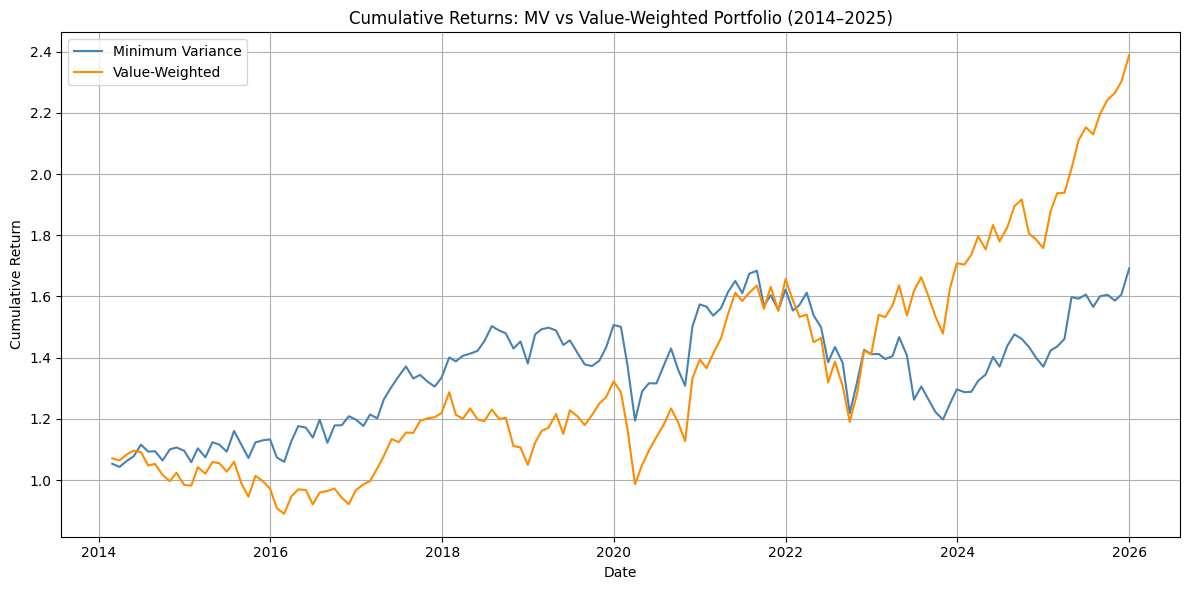


MV Sharpe:  0.2469
VW Sharpe:  0.4316


In [11]:
# Align to common OOS dates
common_oos = mv_returns.index.intersection(vw_returns.index)
mv_oos = mv_returns.loc[common_oos]
vw_oos = vw_returns.loc[common_oos]

cum_mv = (1 + mv_oos).cumprod()
cum_vw = (1 + vw_oos).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cum_mv.index, cum_mv.values, label="Minimum Variance", color="steelblue")
plt.plot(cum_vw.index, cum_vw.values, label="Value-Weighted",   color="darkorange")
plt.title("Cumulative Returns: MV vs Value-Weighted Portfolio (2014–2025)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nMV Sharpe:  {sharpe_mv:.4f}")
print(f"VW Sharpe:  {sharpe_vw:.4f}")